
# Electricity Demand Forecasting (Time Series Project)

## Business Context

#### Objective:
Forecast electricity demand using time series modeling.

#### Goal:
Help in better energy planning and demand management.

## Available Data
Monthly electricity consumption from **January 1973 to December 2019**.

Columns:
- **Date** – Month & Year
- **Consumption** – Electricity consumption (Trillion Watts)

## 1. Import Libraries

In [13]:
import pandas as pd
import pickle
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Load Dataset

In [14]:
# Upload dataset in Colab and update file path if needed
df = pd.read_csv('Electricity Consumption.csv')
df.head()


,DATE,Electricty_Consumption_in_TW
0,1/1/1973,35.9728
1,2/1/1973,36.1334
2,3/1/1973,35.0625
3,4/1/1973,33.8416
4,5/1/1973,33.5107


## 3. EDA

In [15]:
df.describe()       # statistical summary

,Electricty_Consumption_in_TW
count,561.000000
mean,76.681764
std,22.756474
min,33.510700
25%,55.919700
50%,78.417000
75%,93.840600
max,123.216300


In [16]:
df.tail()           # last 5 rows
df.shape            # rows & columns
df.info()           # datatypes
df.isnull().sum()   # check missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   DATE                          561 non-null    object 
 1   Electricty_Consumption_in_TW  561 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.9+ KB


DATE                            0
Electricty_Consumption_in_TW    0
dtype: int64

## 4. Data Preprocessing

In [17]:
df['DATE'] = pd.to_datetime(df['DATE'])   # converts object → datetime
df.dtypes

DATE                            datetime64[ns]
Electricty_Consumption_in_TW           float64
dtype: object

## 5. Set DATE column as index

In [18]:
df.set_index('DATE', inplace=True)
df.index.freq = 'MS'          # MS = Month Start frequency
df.head()                     # verify

,Electricty_Consumption_in_TW
DATE,
1973-01-01,35.9728
1973-02-01,36.1334
1973-03-01,35.0625
1973-04-01,33.8416
1973-05-01,33.5107


## 6. Time Series Visualization

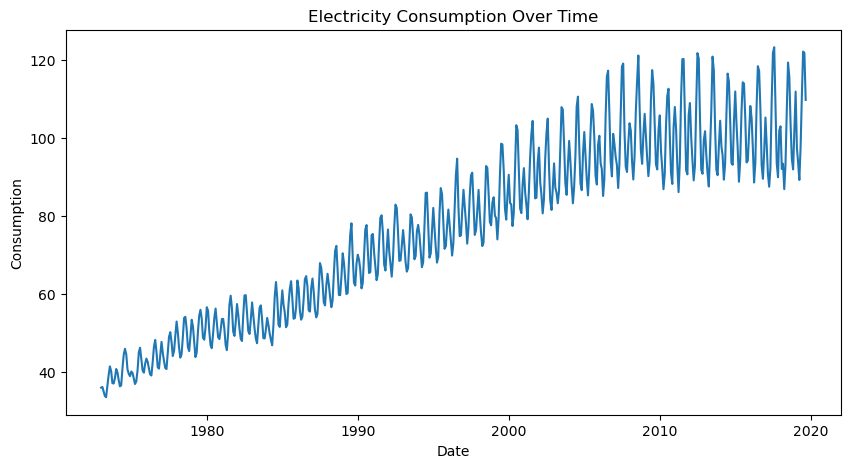

In [24]:
plt.figure(figsize=(10,5))
plt.plot(df['Electricty_Consumption_in_TW'])
plt.title("Electricity Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.show()

## 7. Time Series Decomposition

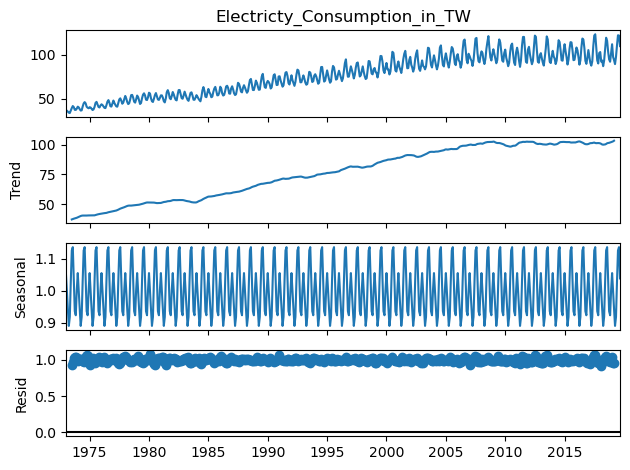

In [33]:
seasonal_decompose(df['Electricty_Consumption_in_TW'], 
                   model='multiplicative', 
                   period=12).plot()
plt.show()

In [21]:
df.columns

Index(['Electricty_Consumption_in_TW'], dtype='object')

## 8. Stationarity Test

In [34]:
result = adfuller(df['Electricty_Consumption_in_TW'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print("✅ Stationary")
else:
    print("❌ Non-Stationary - Differencing needed for ARIMA")

ADF Statistic: -1.7405933729832515
p-value: 0.4103281604468643
❌ Non-Stationary - Differencing needed for ARIMA


## 9. Apply Differencing

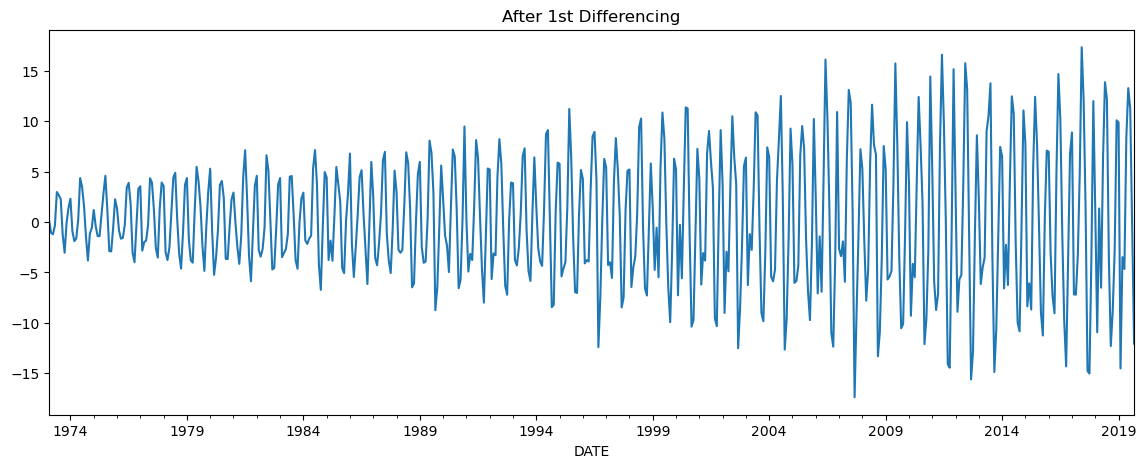

ADF Statistic: -7.941665363981163
p-value: 3.3013438021518788e-12
✅ Stationary after 1st differencing - use d=1


In [35]:
# First order differencing
df_diff = df['Electricty_Consumption_in_TW'].diff().dropna()

# Plot differenced series
df_diff.plot(figsize=(14,5), title='After 1st Differencing')
plt.show()

# Test stationarity again
result = adfuller(df_diff)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print("✅ Stationary after 1st differencing - use d=1")
else:
    print("❌ Still Non-Stationary - need 2nd differencing, use d=2")

## 10. Train-Test-Split

In [36]:
train = df[:-24]    # everything except last 24 months
test  = df[-24:]    # last 24 months

print('Train size:', len(train))
print('Test  size:', len(test))

Train size: 537
Test  size: 24


## 11. ETS Model

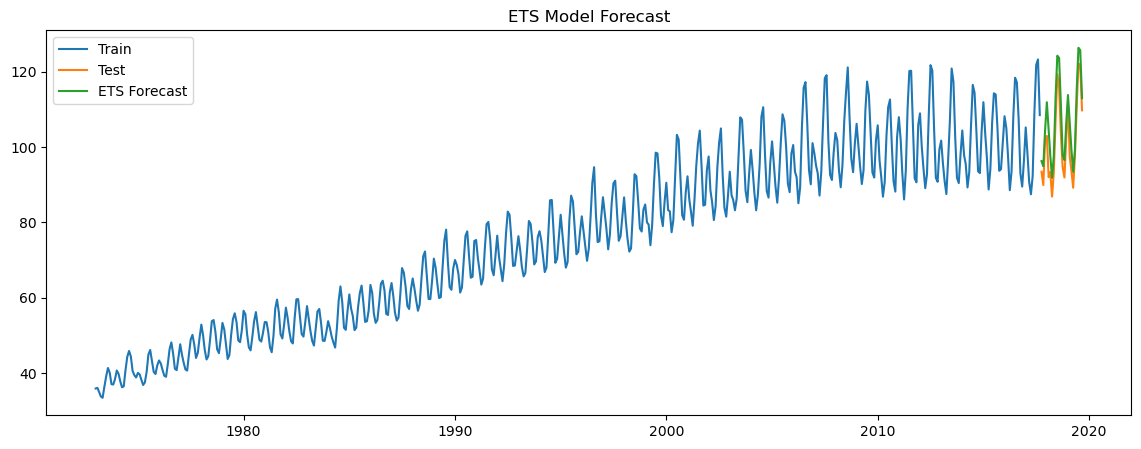

In [37]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
                train['Electricty_Consumption_in_TW'],
                trend='add',           # upward trend present
                seasonal='mul',        # multiplicative seasonality
                seasonal_periods=12    # 12 months
            ).fit()

# Predict on test set
ets_pred = ets_model.forecast(24)

# Plot
plt.figure(figsize=(14,5))
plt.plot(train['Electricty_Consumption_in_TW'], label='Train')
plt.plot(test['Electricty_Consumption_in_TW'],  label='Test')
plt.plot(ets_pred, label='ETS Forecast')
plt.legend()
plt.title('ETS Model Forecast')
plt.show()


## 12. ETS Metrics 

In [41]:
# Define RMSPE function first
def rmspe(actual, predicted):
    return np.sqrt(np.mean(((actual - predicted) / actual) ** 2)) * 100

# Now calculate all metrics
actual = test['Electricty_Consumption_in_TW']

# RMSE
ets_rmse  = np.sqrt(mean_squared_error(actual, ets_pred))

# MAPE
ets_mape  = mean_absolute_percentage_error(actual, ets_pred) * 100

# RMSPE
ets_rmspe = rmspe(actual, ets_pred)

print(f"ETS RMSE  : {ets_rmse:.2f}")
print(f"ETS MAPE  : {ets_mape:.2f}%")
print(f"ETS RMSPE : {ets_rmspe:.2f}%")

ETS RMSE  : 5.66
ETS MAPE  : 5.07%
ETS RMSPE : 5.72%


## 13. Built SARIMA Model 

In [42]:
sarima_model = auto_arima(
                train['Electricty_Consumption_in_TW'],
                seasonal=True,
                m=12,
                d=1,
                stepwise=True,
                trace=True
               )

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=2082.491, Time=0.95 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=2332.043, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=2246.667, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=2151.728, Time=0.19 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=2082.338, Time=0.59 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=2232.298, Time=0.49 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=2081.704, Time=1.14 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=2081.649, Time=1.95 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=2068.393, Time=2.81 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=2076.229, Time=1.58 sec
 ARIMA(1,1,2)(2,1,2)[12]             : AIC=2066.658, Time=1.97 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=2080.961, Time=1.65 sec
 ARIMA(1,1,2)(2,1,1)[12]             : AIC=2074.928, Time=0.96 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=2082.184, Time=0.60 sec
 ARIMA(0,1,2)(2,1,2

## 14. Forecast & Plot SARIMA

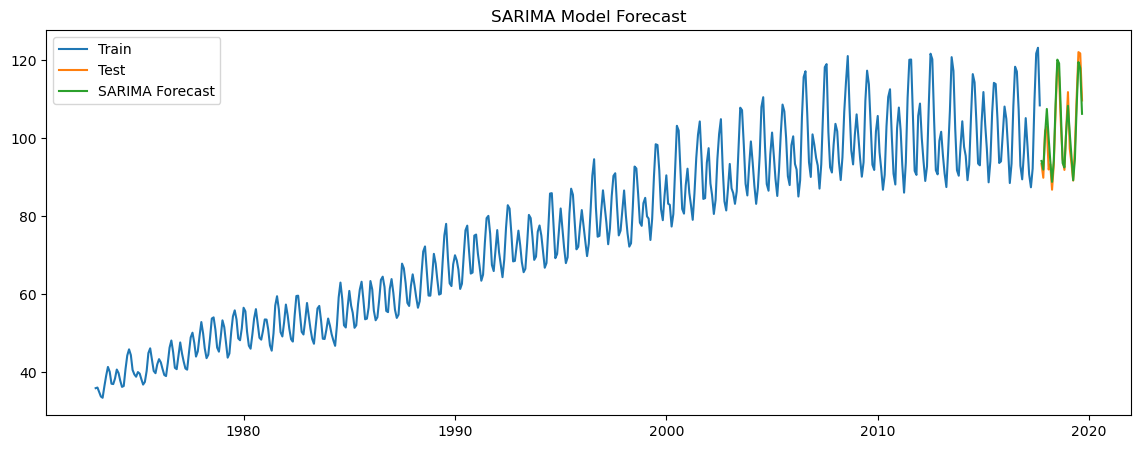

SARIMA RMSE  : 2.91
SARIMA MAPE  : 2.28%
SARIMA RMSPE : 2.90%


In [43]:
# Forecast next 24 months
sarima_pred = sarima_model.predict(n_periods=24)

# Plot
plt.figure(figsize=(14,5))
plt.plot(train['Electricty_Consumption_in_TW'], label='Train')
plt.plot(test['Electricty_Consumption_in_TW'],  label='Test')
plt.plot(test.index, sarima_pred, label='SARIMA Forecast')
plt.legend()
plt.title('SARIMA Model Forecast')
plt.show()

# Metrics
sarima_rmse  = np.sqrt(mean_squared_error(actual, sarima_pred))
sarima_mape  = mean_absolute_percentage_error(actual, sarima_pred) * 100
sarima_rmspe = rmspe(actual, sarima_pred)

print(f"SARIMA RMSE  : {sarima_rmse:.2f}")
print(f"SARIMA MAPE  : {sarima_mape:.2f}%")
print(f"SARIMA RMSPE : {sarima_rmspe:.2f}%")

## 15. Forecast Next 24 Months

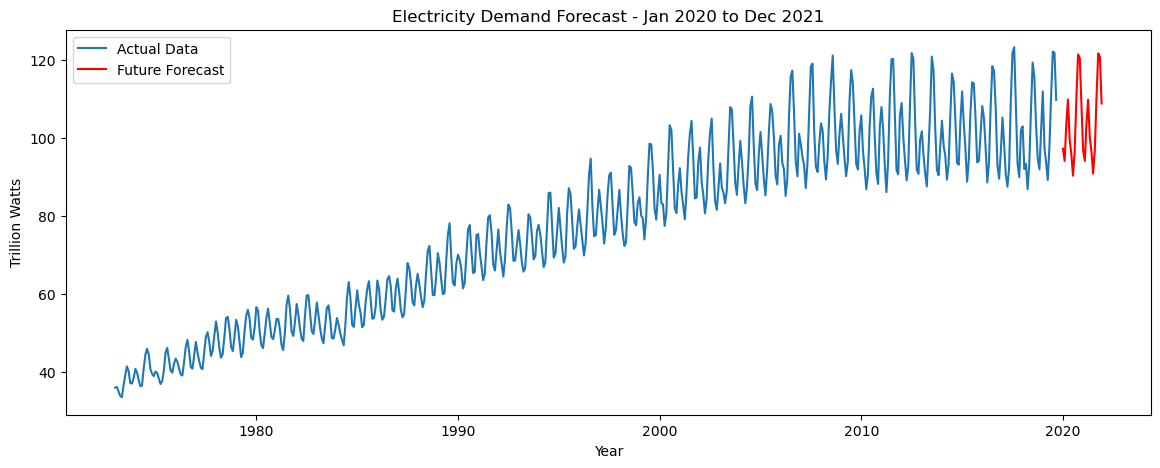

            Forecasted_Consumption
Date                              
2020-01-01               97.205851
2020-02-01               94.080735
2020-03-01              103.278625
2020-04-01              109.825387
2020-05-01               99.727065
2020-06-01               95.832610
2020-07-01               90.274523
2020-08-01               96.709453
2020-09-01              110.400458
2020-10-01              121.344724
2020-11-01              120.485474
2020-12-01              108.521058
2021-01-01               96.640856
2021-02-01               94.091961
2021-03-01              103.456215
2021-04-01              109.763025
2021-05-01              100.231182
2021-06-01               96.422639
2021-07-01               90.827203
2021-08-01               97.065274
2021-09-01              110.748930
2021-10-01              121.633806
2021-11-01              120.705569
2021-12-01              108.805591


In [45]:
# Retrain SARIMA on FULL data (train + test)
final_model = auto_arima(
                df['Electricty_Consumption_in_TW'],
                seasonal=True,
                m=12,
                d=1,
                stepwise=True
              )

# Forecast next 24 months (Jan 2020 - Dec 2021)
future_forecast = final_model.predict(n_periods=24)

# Create future date index
future_dates = pd.date_range(start='2020-01-01', periods=24, freq='MS')

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Consumption': future_forecast
})
forecast_df.set_index('Date', inplace=True)

# Plot final forecast
plt.figure(figsize=(14,5))
plt.plot(df['Electricty_Consumption_in_TW'], label='Actual Data')
plt.plot(forecast_df, label='Future Forecast', color='red')
plt.legend()
plt.title('Electricity Demand Forecast - Jan 2020 to Dec 2021')
plt.xlabel('Year')
plt.ylabel('Trillion Watts')
plt.show()

# Print forecast values
print(forecast_df)

## 16. Forecast Visualization


## Final Model Selection

The **SARIMA model** was selected because it captures both **trend and seasonality** in electricity demand.

It produced the **lowest RMSE, MAPE, and RMSPE** compared with ETS and ARIMA models.
